In [2]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.nlargest(10, "Quantity")[[
    "InvoiceNo", "StockCode", "Quantity", "UnitPrice", "InvoiceDate"
]]

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate
540421,581483,23843,80995,2.08,2011-12-09 09:15:00
61619,541431,23166,74215,1.04,2011-01-18 10:01:00
502122,578841,84826,12540,0.00,2011-11-25 15:57:00
74614,542504,37413,5568,0.00,2011-01-28 12:03:00
421632,573008,84077,4800,0.21,2011-10-27 12:26:00
206121,554868,22197,4300,0.72,2011-05-27 10:52:00
220843,556231,85123A,4000,0.00,2011-06-09 15:04:00
97432,544612,22053,3906,0.82,2011-02-22 10:43:00
270885,560599,18007,3186,0.06,2011-07-19 17:04:00
52711,540815,21108,3114,2.10,2011-01-11 12:55:00


In [3]:
# Preserve the original dataset for before/after comparison.
raw_df = df.copy()

# Print statistics before cleaning.
print("BEFORE CLEANING")
print(f"Rows: {len(raw_df):,}")
print(f"Columns: {raw_df.shape[1]:,}")
print(f"Duplicate rows: {raw_df.duplicated().sum():,}")
print(f"Rows with missing values: {raw_df.isna().any(axis=1).sum():,}")
print(f"Missing values by column:\n{raw_df.isna().sum()}")
print(f"Cancelled invoices: {raw_df['InvoiceNo'].astype(str).str.startswith('C').sum():,}")
print(f"Negative-quantity rows: {(raw_df['Quantity'] < 0).sum():,}")
print(f"Revenue before cleaning: {(raw_df['Quantity'] * raw_df['UnitPrice']).sum():,.2f}")

# Standardize fields required for transaction-level cleaning.
clean_df = raw_df.copy()
clean_df["InvoiceNo"] = clean_df["InvoiceNo"].astype(str).str.strip()
clean_df["StockCode"] = clean_df["StockCode"].astype(str).str.strip()
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"], errors="coerce")
clean_df["Quantity"] = pd.to_numeric(clean_df["Quantity"], errors="coerce")
clean_df["UnitPrice"] = pd.to_numeric(clean_df["UnitPrice"], errors="coerce")

# Remove exact duplicate records before classifying transactions.
clean_df = clean_df.drop_duplicates().copy()

# Identify cancelled and returned transactions before excluding them from sales.
clean_df["IsCancelled"] = clean_df["InvoiceNo"].str.startswith("C")
clean_df["IsReturned"] = clean_df["Quantity"] < 0
returns_df = clean_df[clean_df["IsCancelled"] | clean_df["IsReturned"]].copy()

# Remove rows missing any required field, including CustomerID.
required_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]
clean_df = clean_df.dropna(subset=required_columns).copy()

# Remove invalid prices, non-positive quantities, cancellations, and returns.
non_product_codes = {
    "POST", "DOT", "M", "MANUAL", "D", "DISCOUNT",
    "AMAZONFEE", "BANK CHARGES", "CRUK", "S"
}
clean_df["StockCodeUpper"] = clean_df["StockCode"].str.upper()
clean_df = clean_df[
    (~clean_df["IsCancelled"]) &
    (~clean_df["IsReturned"]) &
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0) &
    (~clean_df["StockCodeUpper"].isin(non_product_codes))
].copy()

# Create revenue after invalid, cancelled, and returned transactions are excluded.
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

# Print statistics after cleaning.
print("\nAFTER CLEANING")
print(f"Rows: {len(clean_df):,}")
print(f"Columns: {clean_df.shape[1]:,}")
print(f"Duplicate rows: {clean_df.duplicated().sum():,}")
print(f"Rows with missing values: {clean_df.isna().any(axis=1).sum():,}")
print(f"Missing values by column:\n{clean_df.isna().sum()}")
print(f"Cancelled/returned rows retained separately: {len(returns_df):,}")
print(f"Revenue after cleaning: {clean_df['Revenue'].sum():,.2f}")
print(f"Rows removed from sales dataset: {len(raw_df) - len(clean_df):,}")

# Display the first rows of the cleaned dataset.
display(clean_df.head())

BEFORE CLEANING
Rows: 541,909
Columns: 8
Duplicate rows: 5,268
Rows with missing values: 135,080
Missing values by column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Cancelled invoices: 9,288
Negative-quantity rows: 10,624
Revenue before cleaning: 9,747,747.93

AFTER CLEANING
Rows: 391,286
Columns: 12
Duplicate rows: 0
Rows with missing values: 0
Missing values by column:
InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
IsCancelled       0
IsReturned        0
StockCodeUpper    0
Revenue           0
dtype: int64
Cancelled/returned rows retained separately: 10,587
Revenue after cleaning: 8,743,913.64
Rows removed from sales dataset: 150,623


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,IsReturned,StockCodeUpper,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,False,85123A,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,71053,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,False,84406B,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,84029G,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,84029E,20.34


MONTHLY SALES CHRONOLOGY


,Month,Revenue,Orders,ItemsSold,AverageOrderValue
0,2010-12-01,565749.56,1395,310632,405.56
1,2011-01-01,562882.91,983,348182,572.62
2,2011-02-01,442493.59,992,264789,446.06
3,2011-03-01,583843.85,1312,347257,445.00
4,2011-04-01,454840.88,1139,291125,399.33
5,2011-05-01,659678.49,1544,372598,427.25
6,2011-06-01,653764.92,1390,362736,470.33
7,2011-07-01,592103.79,1321,367064,448.22
8,2011-08-01,635864.38,1268,397106,501.47
9,2011-09-01,939652.63,1740,542844,540.03


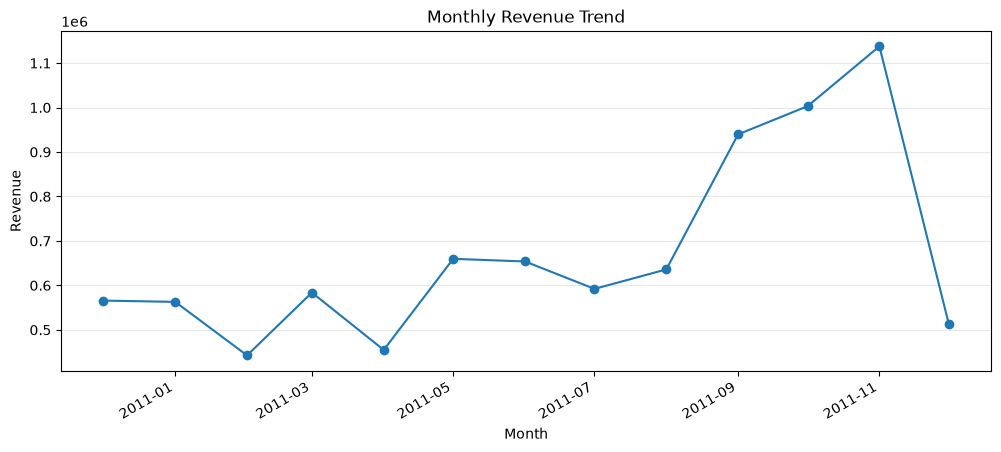

In [4]:
# Analyze monthly sales chronology from the cleaned merchandise-sales dataset.
import matplotlib.pyplot as plt

monthly_sales = (
    clean_df.assign(Month=clean_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        ItemsSold=("Quantity", "sum"),
    )
)

monthly_sales["AverageOrderValue"] = (
    monthly_sales["Revenue"] / monthly_sales["Orders"]
)

print("MONTHLY SALES CHRONOLOGY")
display(monthly_sales.round({"Revenue": 2, "AverageOrderValue": 2}))

fig, axis = plt.subplots(figsize=(12, 5))
axis.plot(monthly_sales["Month"], monthly_sales["Revenue"], marker="o")
axis.set_title("Monthly Revenue Trend")
axis.set_xlabel("Month")
axis.set_ylabel("Revenue")
axis.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
plt.show()

In [5]:
# Identify the products that drive revenue, volume, and customer reach.
product_performance = (
    clean_df.groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        QuantitySold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
        AverageUnitPrice=("UnitPrice", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)

print("TOP PRODUCTS BY REVENUE")
display(product_performance.head(10).round({"Revenue": 2, "AverageUnitPrice": 2}))

print("TOP PRODUCTS BY QUANTITY")
display(
    product_performance.sort_values("QuantitySold", ascending=False)
    .head(10)
    .round({"Revenue": 2, "AverageUnitPrice": 2})
)

TOP PRODUCTS BY REVENUE


,StockCode,Description,Revenue,QuantitySold,Orders,Customers,AverageUnitPrice
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1,2.08
1318,22423,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703,881,12.48
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971,856,2.89
3444,85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600,635,2.02
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195,138,1.22
2799,47566,PARTY BUNTING,68785.23,15279,1379,708,4.88
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375,678,1.68
2006,23084,RABBIT NIGHT LIGHT,51251.24,27153,801,450,2.01
2960,79321,CHILLI LIGHTS,46265.11,9646,519,205,5.43
1001,22086,PAPER CHAIN KIT 50'S CHRISTMAS,42584.13,15591,980,613,2.94


TOP PRODUCTS BY QUANTITY


,StockCode,Description,Revenue,QuantitySold,Orders,Customers,AverageUnitPrice
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1,2.08
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195,138,1.22
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13558.41,54319,472,307,0.29
3444,85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600,635,2.02
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971,856,2.89
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375,678,1.68
432,21212,PACK OF 72 RETROSPOT CAKE CASES,16381.88,33670,1029,635,0.55
1108,22197,POPCORN HOLDER,23417.51,30919,632,295,0.84
2006,23084,RABBIT NIGHT LIGHT,51251.24,27153,801,450,2.01
1383,22492,MINI PAINT SET VINTAGE,16039.24,26076,325,213,0.66


In [6]:
# Summarize customer recency, frequency, and monetary value.
analysis_date = clean_df["InvoiceDate"].max().normalize()

customer_rfm = (
    clean_df.groupby("CustomerID", as_index=False)
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        MonetaryValue=("Revenue", "sum"),
        ItemsPurchased=("Quantity", "sum"),
    )
)
customer_rfm["RecencyDays"] = (
    analysis_date - customer_rfm["LastPurchase"].dt.normalize()
).dt.days

customer_rfm = customer_rfm[
    [
        "CustomerID", "RecencyDays", "Frequency", "MonetaryValue",
        "ItemsPurchased", "LastPurchase",
    ]
].sort_values("MonetaryValue", ascending=False)

print("TOP CUSTOMERS BY MONETARY VALUE")
display(customer_rfm.head(10).round({"MonetaryValue": 2}))

print("CUSTOMER RFM SUMMARY")
display(customer_rfm[["RecencyDays", "Frequency", "MonetaryValue"]].describe().round(2))

TOP CUSTOMERS BY MONETARY VALUE


,CustomerID,RecencyDays,Frequency,MonetaryValue,ItemsPurchased,LastPurchase
1689,14646.0,1,72,279138.02,196844,2011-12-08 12:12:00
4197,18102.0,0,60,259657.30,64124,2011-12-09 11:50:00
3725,17450.0,8,46,194390.79,69973,2011-12-01 13:29:00
3006,16446.0,0,2,168472.50,80997,2011-12-09 09:15:00
1879,14911.0,1,199,140336.83,80238,2011-12-08 15:54:00
55,12415.0,24,20,124564.53,77373,2011-11-15 14:22:00
1333,14156.0,9,55,117210.08,57768,2011-11-30 10:54:00
3768,17511.0,2,31,91062.38,64549,2011-12-07 10:12:00
0,12346.0,325,1,77183.60,74215,2011-01-18 10:01:00
2700,16029.0,38,62,72708.09,40107,2011-11-01 10:27:00


CUSTOMER RFM SUMMARY


,RecencyDays,Frequency,MonetaryValue
count,4334.00,4334.00,4334.00
mean,92.23,4.25,2017.52
std,100.18,7.64,8920.36
min,0.00,1.00,3.75
25%,17.00,1.00,304.30
50%,50.00,2.00,663.71
75%,142.00,5.00,1631.62
max,373.00,206.00,279138.02


In [7]:
# Compare geographic performance using revenue, orders, and identifiable customers.
country_performance = (
    clean_df.groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
        ItemsSold=("Quantity", "sum"),
    )
)
country_performance["AverageOrderValue"] = (
    country_performance["Revenue"] / country_performance["Orders"]
)
country_performance = country_performance.sort_values("Revenue", ascending=False)

print("TOP COUNTRIES BY REVENUE")
display(country_performance.head(15).round({"Revenue": 2, "AverageOrderValue": 2}))

print("COUNTRIES BY AVERAGE ORDER VALUE, MINIMUM 10 ORDERS")
display(
    country_performance[country_performance["Orders"] >= 10]
    .sort_values("AverageOrderValue", ascending=False)
    .head(10)
    .round({"Revenue": 2, "AverageOrderValue": 2})
)

TOP COUNTRIES BY REVENUE


,Country,Revenue,Orders,Customers,ItemsSold,AverageOrderValue
35,United Kingdom,7244330.32,16579,3916,4234345,436.96
23,Netherlands,283889.34,93,9,200258,3052.57
10,EIRE,261888.12,258,3,140131,1015.07
14,Germany,205381.15,443,94,118032,463.61
13,France,183987.94,380,87,110597,484.18
0,Australia,138103.81,56,9,83890,2466.14
30,Spain,55706.56,88,30,27724,633.03
32,Switzerland,52441.95,47,21,29980,1115.79
19,Japan,37416.37,19,8,26016,1969.28
3,Belgium,36927.34,98,25,22962,376.81


COUNTRIES BY AVERAGE ORDER VALUE, MINIMUM 10 ORDERS


,Country,Revenue,Orders,Customers,ItemsSold,AverageOrderValue
23,Netherlands,283889.34,93,9,200258,3052.57
0,Australia,138103.81,56,9,83890,2466.14
19,Japan,37416.37,19,8,26016,1969.28
32,Switzerland,52441.95,47,21,29980,1115.79
31,Sweden,36828.83,34,8,36037,1083.20
10,EIRE,261888.12,258,3,140131,1015.07
24,Norway,32454.64,32,10,19276,1014.21
9,Denmark,18211.34,18,9,8193,1011.74
7,Cyprus,13167.16,14,8,6338,940.51
6,Channel Islands,20147.54,25,9,9484,805.90


In [8]:
# Quantify cancellations and returns separately from qualifying sales.
returns_analysis = returns_df.copy()
returns_analysis["ReturnValue"] = (
    returns_analysis["Quantity"].abs() * returns_analysis["UnitPrice"].abs()
)
returns_analysis["EventType"] = returns_analysis["IsCancelled"].map(
    {True: "Cancelled invoice", False: "Returned quantity"}
)

return_summary = (
    returns_analysis.groupby("EventType", as_index=False)
    .agg(
        Rows=("InvoiceNo", "size"),
        Invoices=("InvoiceNo", "nunique"),
        ItemsAffected=("Quantity", lambda values: values.abs().sum()),
        ReturnValue=("ReturnValue", "sum"),
    )
)

product_returns = (
    returns_analysis.groupby(["StockCode", "Description"], dropna=False, as_index=False)
    .agg(
        Rows=("InvoiceNo", "size"),
        ItemsAffected=("Quantity", lambda values: values.abs().sum()),
        ReturnValue=("ReturnValue", "sum"),
    )
    .sort_values("ReturnValue", ascending=False)
)

print("RETURN AND CANCELLATION SUMMARY")
display(return_summary.round({"ReturnValue": 2}))

print("PRODUCTS WITH THE HIGHEST RETURN VALUE")
display(product_returns.head(10).round({"ReturnValue": 2}))

RETURN AND CANCELLATION SUMMARY


,EventType,Rows,Invoices,ItemsAffected,ReturnValue
0,Cancelled invoice,9251,3836,275560,893979.73
1,Returned quantity,1336,1336,206957,0.00


PRODUCTS WITH THE HIGHEST RETURN VALUE


,StockCode,Description,Rows,ItemsAffected,ReturnValue
3162,AMAZONFEE,AMAZON FEE,32,32,235281.59
2182,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
3180,M,Manual,244,4066,146784.46
1901,23166,MEDIUM CERAMIC TOP STORAGE JAR,10,74494,77479.64
3181,POST,POSTAGE,126,147,11871.24
1183,22423,REGENCY CAKESTAND 3 TIER,180,855,9697.05
3165,CRUK,CRUK Commission,16,16,7933.43
3163,BANK CHARGES,Bank Charges,25,25,7340.64
2972,85123A,WHITE HANGING HEART T-LIGHT HOLDER,42,2578,6624.30
283,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3,3150,6591.42


In [9]:
# Create practical demand signals for inventory planning.
inventory_signals = product_performance.copy()
inventory_signals["ItemsPerOrder"] = (
    inventory_signals["QuantitySold"] / inventory_signals["Orders"]
)
inventory_signals["RevenuePerOrder"] = (
    inventory_signals["Revenue"] / inventory_signals["Orders"]
)

print("RECURRING HIGH-DEMAND PRODUCTS")
display(
    inventory_signals[inventory_signals["Orders"] >= 100]
    .sort_values("QuantitySold", ascending=False)
    .head(15)
    .round({"Revenue": 2, "AverageUnitPrice": 2, "ItemsPerOrder": 2, "RevenuePerOrder": 2})
)

print("HIGH-VOLUME PRODUCTS WITH FEW ORDERS: AUDIT CANDIDATES")
display(
    inventory_signals[
        (inventory_signals["QuantitySold"] >= 10000) &
        (inventory_signals["Orders"] <= 10)
    ]
    .sort_values("QuantitySold", ascending=False)
    .head(15)
    .round({"Revenue": 2, "AverageUnitPrice": 2, "ItemsPerOrder": 2, "RevenuePerOrder": 2})
)

RECURRING HIGH-DEMAND PRODUCTS


,StockCode,Description,Revenue,QuantitySold,Orders,Customers,AverageUnitPrice,ItemsPerOrder,RevenuePerOrder
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195,138,1.22,399.57,417.52
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13558.41,54319,472,307,0.29,115.08,28.73
3444,85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600,635,2.02,28.80,53.15
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971,856,2.89,18.62,50.93
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375,678,1.68,25.65,41.03
432,21212,PACK OF 72 RETROSPOT CAKE CASES,16381.88,33670,1029,635,0.55,32.72,15.92
1108,22197,POPCORN HOLDER,23417.51,30919,632,295,0.84,48.92,37.05
2006,23084,RABBIT NIGHT LIGHT,51251.24,27153,801,450,2.01,33.90,63.98
1383,22492,MINI PAINT SET VINTAGE,16039.24,26076,325,213,0.66,80.23,49.35
1505,22616,PACK OF 12 LONDON TISSUES,7261.77,25329,382,195,0.33,66.31,19.01


HIGH-VOLUME PRODUCTS WITH FEW ORDERS: AUDIT CANDIDATES


,StockCode,Description,Revenue,QuantitySold,Orders,Customers,AverageUnitPrice,ItemsPerOrder,RevenuePerOrder
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.6,80995,1,1,2.08,80995.0,168469.6


In [10]:
# Examine price bands and common product pairings for merchandising decisions.
price_band_df = clean_df.copy()
price_band_df["PriceBand"] = pd.cut(
    price_band_df["UnitPrice"],
    bins=[0, 1, 5, 10, 25, 50, float("inf")],
    labels=["GBP 0-1", "GBP 1-5", "GBP 5-10", "GBP 10-25", "GBP 25-50", "GBP 50+"],
    right=False,
)

price_band_performance = (
    price_band_df.groupby("PriceBand", observed=False, as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        ItemsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Products=("StockCode", "nunique"),
    )
)

print("PERFORMANCE BY UNIT-PRICE BAND")
display(price_band_performance.round({"Revenue": 2}))

# Count distinct product pairs within each invoice for cross-sell signals.
from collections import Counter
from itertools import combinations

pair_counts = Counter()
for products in clean_df.groupby("InvoiceNo")["StockCode"].unique():
    pair_counts.update(combinations(sorted(products), 2))

product_names = (
    clean_df[["StockCode", "Description"]]
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
    .to_dict()
)

common_pairs = pd.DataFrame(
    [
        {
            "StockCodeA": first_code,
            "ProductA": product_names.get(first_code, "Unknown"),
            "StockCodeB": second_code,
            "ProductB": product_names.get(second_code, "Unknown"),
            "OrdersTogether": count,
        }
        for (first_code, second_code), count in pair_counts.most_common(15)
    ]
)

print("MOST COMMON PRODUCT PAIRS")
display(common_pairs)

PERFORMANCE BY UNIT-PRICE BAND


,PriceBand,Revenue,ItemsSold,Orders,Products
0,GBP 0-1,1042977.87,2027597,13290,1234
1,GBP 1-5,6034155.99,2921232,17552,2630
2,GBP 5-10,1137830.58,158081,11410,723
3,GBP 10-25,424668.16,33765,5295,256
4,GBP 25-50,28184.44,806,342,24
5,GBP 50+,76096.60,440,271,11


MOST COMMON PRODUCT PAIRS


,StockCodeA,ProductA,StockCodeB,ProductB,OrdersTogether
0,22386,JUMBO BAG PINK POLKADOT,85099B,JUMBO BAG RED RETROSPOT,546
1,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,541
2,22726,ALARM CLOCK BAKELIKE GREEN,22727,ALARM CLOCK BAKELIKE RED,530
3,20725,LUNCH BAG RED RETROSPOT,22384,LUNCH BAG PINK POLKADOT,523
4,20725,LUNCH BAG RED RETROSPOT,22383,LUNCH BAG SUKI DESIGN,519
5,20725,LUNCH BAG RED RETROSPOT,20727,LUNCH BAG BLACK SKULL.,517
6,82482,WOODEN PICTURE FRAME WHITE FINISH,82494L,WOODEN FRAME ANTIQUE WHITE,468
7,23203,JUMBO BAG DOILEY PATTERNS,85099B,JUMBO BAG RED RETROSPOT,468
8,20725,LUNCH BAG RED RETROSPOT,22382,LUNCH BAG SPACEBOY DESIGN,467
9,20727,LUNCH BAG BLACK SKULL.,22383,LUNCH BAG SUKI DESIGN,465


TOTAL SALES BY COUNTRY


,Country,TotalSales
35,United Kingdom,7244330.32
23,Netherlands,283889.34
10,EIRE,261888.12
14,Germany,205381.15
13,France,183987.94
0,Australia,138103.81
30,Spain,55706.56
32,Switzerland,52441.95
19,Japan,37416.37
3,Belgium,36927.34


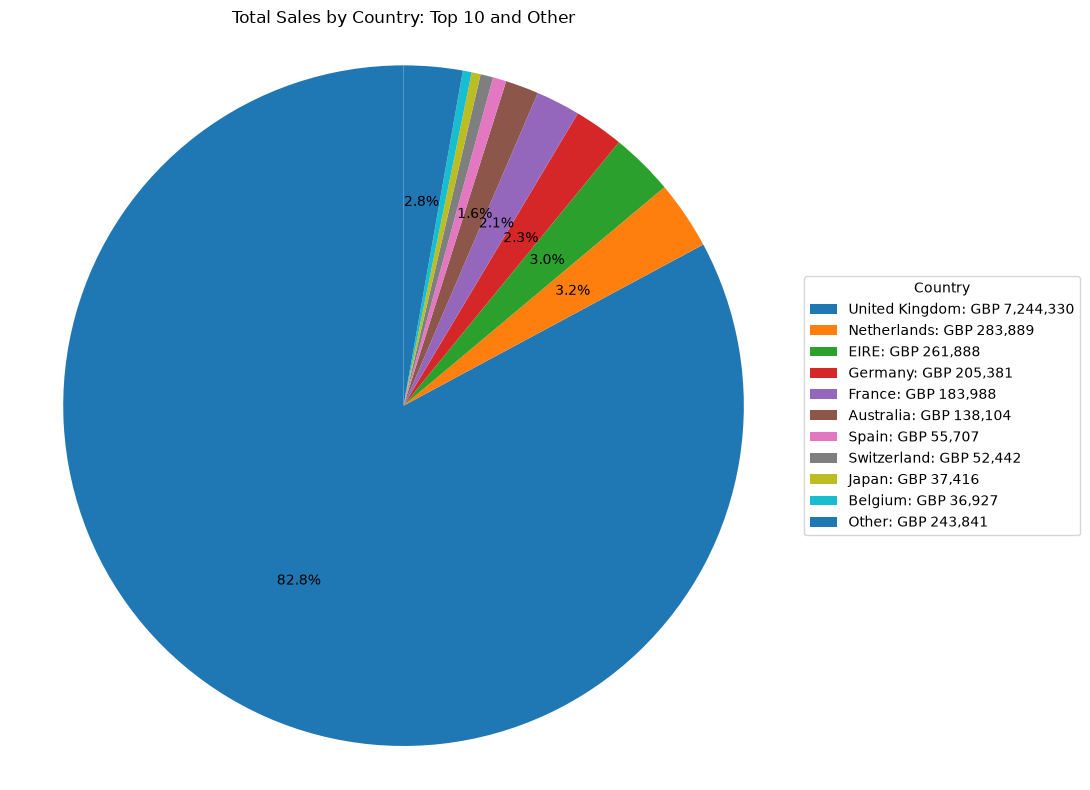

In [13]:
# Report total sales by country in descending order and visualize the distribution.
import matplotlib.pyplot as plt

country_sales = (
    clean_df.groupby("Country", as_index=False)
    .agg(TotalSales=("Revenue", "sum"))
    .sort_values("TotalSales", ascending=False)
)

print("TOTAL SALES BY COUNTRY")
display(country_sales.round({"TotalSales": 2}))

pie_data = country_sales.head(10).copy()
other_sales = country_sales.iloc[10:]["TotalSales"].sum()

if other_sales > 0:
    pie_data = pd.concat(
        [
            pie_data,
            pd.DataFrame({"Country": ["Other"], "TotalSales": [other_sales]}),
        ],
        ignore_index=True,
    )

fig, axis = plt.subplots(figsize=(11, 8))
wedges, _, _ = axis.pie(
    pie_data["TotalSales"],
    autopct=lambda percentage: f"{percentage:.1f}%" if percentage >= 1 else "",
    startangle=90,
)
legend_labels = [
    f"{country}: GBP {sales:,.0f}"
    for country, sales in zip(pie_data["Country"], pie_data["TotalSales"])
]
axis.legend(
    wedges,
    legend_labels,
    title="Country",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
axis.set_title("Total Sales by Country: Top 10 and Other")
axis.axis("equal")
plt.tight_layout()
plt.show()

In [14]:
# Rank products by total sales revenue in descending order.
product_sales = (
    clean_df.groupby(["StockCode", "Description"], as_index=False)
    .agg(
        TotalSales=("Revenue", "sum"),
        QuantitySold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .sort_values("TotalSales", ascending=False)
)

print("PRODUCTS RANKED BY TOTAL SALES")
display(product_sales.head(20).round({"TotalSales": 2}))

highest_sales_product = product_sales.iloc[0]
print(
    f"Highest-sales product: {highest_sales_product['Description']} "
    f"({highest_sales_product['StockCode']}) - "
    f"GBP {highest_sales_product['TotalSales']:,.2f}"
)

PRODUCTS RANKED BY TOTAL SALES


,StockCode,Description,TotalSales,QuantitySold,Orders
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1318,22423,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
3444,85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
2799,47566,PARTY BUNTING,68785.23,15279,1379
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
2006,23084,RABBIT NIGHT LIGHT,51251.24,27153,801
2960,79321,CHILLI LIGHTS,46265.11,9646,519
1001,22086,PAPER CHAIN KIT 50'S CHRISTMAS,42584.13,15591,980


Highest-sales product: PAPER CRAFT , LITTLE BIRDIE (23843) - GBP 168,469.60


In [15]:
# Estimate revenue contribution by product category from product descriptions.
# The source data has no category field, so this is a transparent keyword-based proxy.
category_rules = {
    "Bags and Accessories": r"BAG|PURSE|WALLET|SCARF|HAT|GLOVE|JEWEL|RING",
    "Home and Kitchen": r"CAKE|CUP|MUG|KITCHEN|JAR|BOWL|PLATE|TEA|FRAME|DOORMAT|T-LIGHT|LIGHT|HOLDER",
    "Decorations and Gifts": r"HEART|ORNAMENT|BUNTING|CHRISTMAS|DECORATION|CANDLE|SIGN",
    "Toys and Crafts": r"TOY|GAME|DOLL|PUZZLE|GLIDER|PAINT|KITE",
    "Stationery and Packaging": r"PAPER|PENCIL|PEN|NOTEBOOK|CARD|TISSUE|CAKE CASE|ENVELOPE",
    "Garden and Outdoor": r"GARDEN|PLANT|FLOWER|PICNIC",
}

category_df = clean_df.copy()
category_df["Category"] = "Other / Unclassified"
product_descriptions = category_df["Description"].fillna("").str.upper()

for category, pattern in category_rules.items():
    matches = product_descriptions.str.contains(pattern, regex=True, na=False)
    category_df.loc[
        (category_df["Category"] == "Other / Unclassified") & matches,
        "Category",
    ] = category

category_sales = (
    category_df.groupby("Category", as_index=False)
    .agg(
        TotalSales=("Revenue", "sum"),
        QuantitySold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Products=("StockCode", "nunique"),
    )
    .sort_values("TotalSales", ascending=False)
)
category_sales["RevenueSharePct"] = (
    category_sales["TotalSales"] / category_sales["TotalSales"].sum() * 100
)

print("ESTIMATED CATEGORY CONTRIBUTION TO REVENUE")
display(category_sales.round({"TotalSales": 2, "RevenueSharePct": 2}))

ESTIMATED CATEGORY CONTRIBUTION TO REVENUE


,Category,TotalSales,QuantitySold,Orders,Products,RevenueSharePct
4,Other / Unclassified,2685658.79,1410580,15827,1505,30.71
3,Home and Kitchen,2479828.30,1246770,15104,657,28.36
1,Decorations and Gifts,1627712.98,1042558,13716,624,18.62
0,Bags and Accessories,1070109.66,724042,10676,425,12.24
5,Stationery and Packaging,462916.28,503520,7745,236,5.29
2,Garden and Outdoor,225527.92,88447,5008,150,2.58
6,Toys and Crafts,192159.71,126004,4960,81,2.20


In [ ]:
# Visualize estimated category sales and revenue share.
import matplotlib.pyplot as plt

category_chart = category_sales.sort_values("TotalSales", ascending=True)

fig, axis = plt.subplots(figsize=(11, 6))
axis.barh(category_chart["Category"], category_chart["TotalSales"])
axis.set_title("Estimated Sales by Product Category")
axis.set_xlabel("Total Sales (GBP)")
axis.set_ylabel("Category")
axis.grid(axis="x", alpha=0.3)

for position, sales in enumerate(category_chart["TotalSales"]):
    axis.text(sales, position, f" GBP {sales:,.0f}", va="center")

plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(9, 7))
wedges, _, _ = axis.pie(
    category_sales["TotalSales"],
    autopct=lambda percentage: f"{percentage:.1f}%" if percentage >= 3 else "",
    startangle=90,
)
axis.legend(
    wedges,
    [
        f"{category}: {share:.1f}%"
        for category, share in zip(
            category_sales["Category"], category_sales["RevenueSharePct"]
        )
    ],
    title="Category Revenue Share",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
axis.set_title("Estimated Category Revenue Share")
axis.axis("equal")
plt.tight_layout()
plt.show()